In [ ]:
!cp -r /content/drive/MyDrive/photodata /content/

cp: cannot stat '/content/drive/MyDrive/photodata': No such file or directory


In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os
from google.colab import drive
from google.colab import files
from PIL import Image
import io
from tensorflow.keras.preprocessing import image

In [ ]:
drive.mount('/content/drive')
modelPath = "/content/drive/MyDrive/photodata/pneumoniaClassifierNormal.keras"

Mounted at /content/drive


In [ ]:
model = keras.models.load_model(modelPath)

In [ ]:
def normalize(image):
    image = tf.cast(image, tf.float32) / 255.0
    return image

Step 1: Upload an image


Saving pneumonia-583.jpg to pneumonia-583.jpg
Image loaded: pneumonia-583.jpg

Step 2: Running prediction
Prediction  : Pneumonia
Confidence  : 83.5 %

Step 3: Searching for last conv layer
Using conv layer: conv2d_3

Step 4: Computing Grad-CAM
Heatmap computed

Step 5: Overlaying heatmap


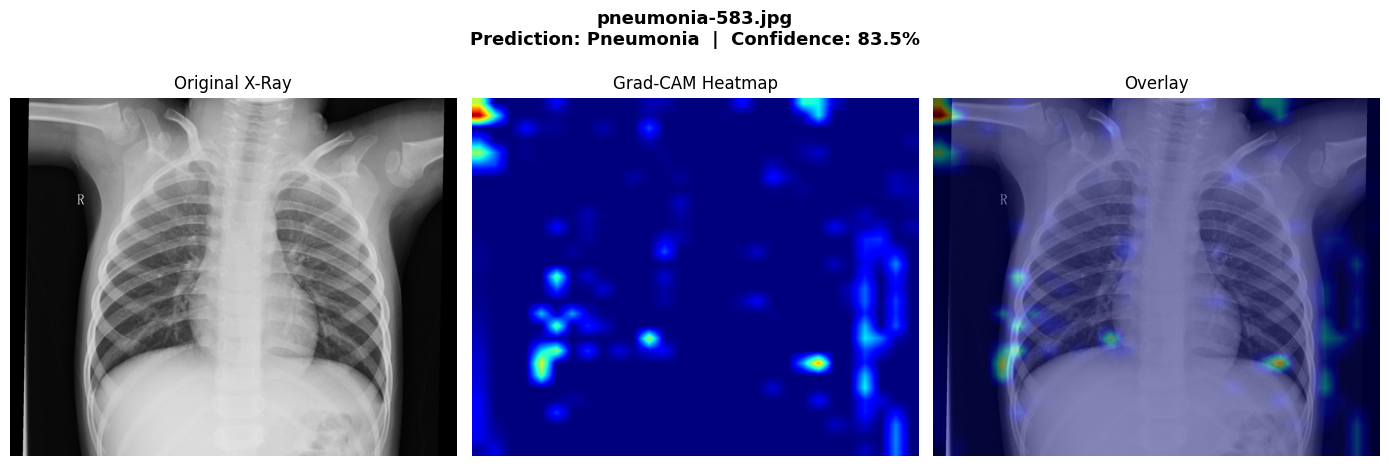

Done.


In [21]:
# --- Pneumonia Classifier with Grad-CAM ---
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import io
from tensorflow.keras.preprocessing import image
from google.colab import files

IMAGE_SIZE = (64, 64)
CLASS_NAMES = ["Normal", "Pneumonia"]

# -----------------------------
# UPLOAD IMAGE
# -----------------------------
print("Step 1: Upload an image")
uploaded = files.upload()
fname = list(uploaded.keys())[0]
data = uploaded[fname]

img = image.load_img(io.BytesIO(data), target_size=IMAGE_SIZE)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0
print("Image loaded:", fname)

# -----------------------------
# RUN PREDICTION
# -----------------------------
print("\nStep 2: Running prediction")
prediction = model.predict(img_array, verbose=0)
prob = float(prediction[0][0])
label_idx = int(prob >= 0.5)
label = CLASS_NAMES[label_idx]
confidence = prob if label_idx == 1 else 1 - prob
print("Prediction  :", label)
print("Confidence  :", round(confidence * 100, 1), "%")

# -----------------------------
# FIND LAST CONV LAYER
# -----------------------------
print("\nStep 3: Searching for last conv layer")
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break
print("Using conv layer:", last_conv_layer_name)

# -----------------------------
# COMPUTE GRADIENTS
# Manual layer-by-layer forward pass inside GradientTape —
# same approach as your teacher's code, works with Sequential + Keras 3.
# -----------------------------
print("\nStep 4: Computing Grad-CAM")
last_conv_layer = model.get_layer(last_conv_layer_name)
last_conv_idx = model.layers.index(last_conv_layer)

img_tensor = tf.convert_to_tensor(img_array)

with tf.GradientTape() as tape:
    x = img_tensor
    for i, layer in enumerate(model.layers):
        x = layer(x)
        if i == last_conv_idx:
            conv_outputs = x
            tape.watch(conv_outputs)
    predictions = x
    class_channel = predictions[:, 0]

grads = tape.gradient(class_channel, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_map = conv_outputs[0]
heatmap = tf.reduce_sum(conv_map * pooled_grads, axis=-1)
heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
heatmap = heatmap.numpy()
print("Heatmap computed")

# -----------------------------
# OVERLAY HEATMAP
# -----------------------------
print("\nStep 5: Overlaying heatmap")
orig_img = np.array(image.load_img(io.BytesIO(data)))  # original full-res, no resize
h, w = orig_img.shape[:2]

heatmap_resized = cv2.resize(heatmap, (w, h))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

# cv2 loads BGR, matplotlib expects RGB
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
overlay = cv2.addWeighted(orig_img, 0.6, heatmap_colored, 0.4, 0)

# -----------------------------
# DISPLAY
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(f"{fname}\nPrediction: {label}  |  Confidence: {confidence*100:.1f}%",
             fontsize=13, fontweight="bold")

axes[0].imshow(orig_img)
axes[0].set_title("Original X-Ray")
axes[0].axis("off")

axes[1].imshow(heatmap_resized, cmap="jet")
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()
print("Done.")